In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
!pip install imbalanced-learn

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Class
0.0    63306
1.0      165
Name: count, dtype: int64


<Axes: xlabel='Class', ylabel='count'>

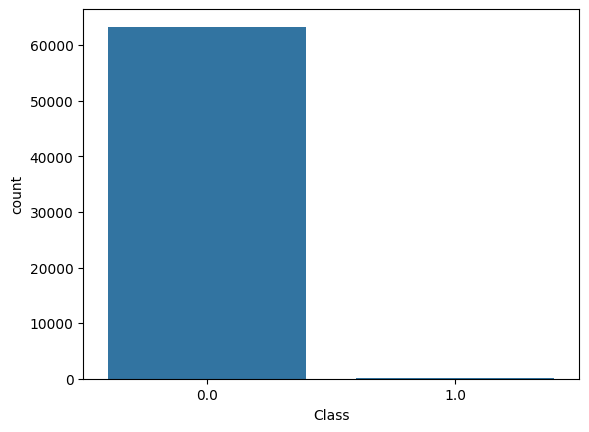

In [ ]:
print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)

In [ ]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df.drop(['Time', 'Amount'], axis=1, inplace=True)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Drop rows with NaN in 'Class' column
df.dropna(subset=['Class'], inplace=True)

rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(df.drop('Class', axis=1), df['Class'])
df_rus = pd.DataFrame(X_rus, columns=df.columns[:-1])
df_rus['Class'] = y_rus

In [ ]:
def create_sequences(data, time_steps=10):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data.iloc[i:i+time_steps].drop(columns='Class').values)
        y.append(data.iloc[i+time_steps]['Class'])
    return np.array(X), np.array(y)

In [ ]:
X_seq, y_seq = create_sequences(df_rus)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.7063 - loss: 0.5995 - val_accuracy: 0.8125 - val_loss: 0.4776
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8984 - loss: 0.4329 - val_accuracy: 0.8906 - val_loss: 0.3645
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9505 - loss: 0.3230 - val_accuracy: 0.9531 - val_loss: 0.2914
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9755 - loss: 0.2564 - val_accuracy: 1.0000 - val_loss: 0.2302
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9917 - loss: 0.1950 - val_accuracy: 0.9844 - val_loss: 0.1731


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9896 - loss: 0.1764 
Test Accuracy: 0.984375


In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        31
         1.0       1.00      0.97      0.98        33

    accuracy                           0.98        64
   macro avg       0.98      0.98      0.98        64
weighted avg       0.98      0.98      0.98        64

ROC AUC Score: 0.9848484848484849


<Axes: >

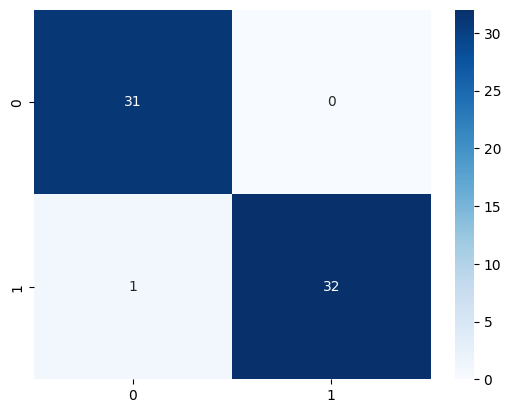

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5b9bc40b2b3f69158c7a57a44a89fdaf3f807d239956e1a153af361cc2493abe
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from lime import lime_tabular

# Flatten the LSTM input for LIME (only if LSTM used, else skip)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Create a wrapper function for the model's predict method to handle LIME's input shape
def predict_wrapper(x):
    # Reshape the flattened input back to the original 3D shape (samples, time_steps, features)
    # X_test.shape[1] is the number of time steps, X_test.shape[2] is the number of features
    x_reshaped = x.reshape(x.shape[0], X_test.shape[1], X_test.shape[2])
    # Get the probability of the positive class
    prob_positive = model.predict(x_reshaped)
    # Return probabilities for both classes
    return np.hstack((1 - prob_positive, prob_positive))


explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_flat,
    feature_names=[f'f{i}' for i in range(X_train_flat.shape[1])],
    class_names=['Legit', 'Fraud'],
    mode='classification'
)

# Explain a single prediction
i = 0
exp = explainer.explain_instance(X_test_flat[i], predict_wrapper, num_features=10)
exp.show_in_notebook()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
def simulate_real_time(sequence):
    prediction = model.predict(np.expand_dims(sequence, axis=0))[0][0]
    return "FRAUD" if prediction > 0.5 else "LEGIT"

In [ ]:
print("Prediction:", simulate_real_time(X_test[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction: FRAUD


In [ ]:
exp = explainer.explain_instance(X_test_flat[0], predict_wrapper, num_features=10)
print(exp.as_list())

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[('f187 <= -8.07', 0.009028517819751456), ('-5.84 < f263 <= -0.49', 0.008742490456517654), ('-7.75 < f272 <= -2.37', 0.007957021741333472), ('f190 > 0.24', -0.007254556295640595), ('f261 > 0.93', -0.007130413875522426), ('f158 <= -7.85', 0.006304523256089901), ('f148 > 5.59', 0.0062222445791954096), ('f161 > 0.28', -0.005609907077767615), ('f90 > 5.70', 0.004926245757922179), ('-6.44 < f270 <= -0.87', 0.004064480923961522)]


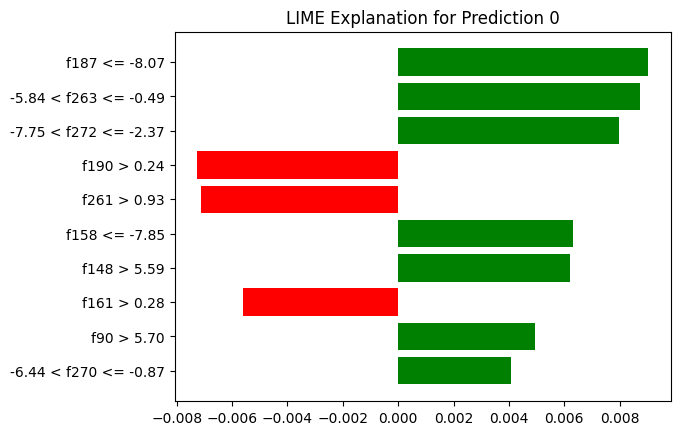

In [ ]:
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation for Prediction 0")
plt.show()

In [ ]:
for i in range(3):
    exp = explainer.explain_instance(X_test_flat[i], predict_wrapper, num_features=5)
    exp.show_in_notebook()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Precision: 1.0000, Recall: 0.9697, F1 Score: 0.9846


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


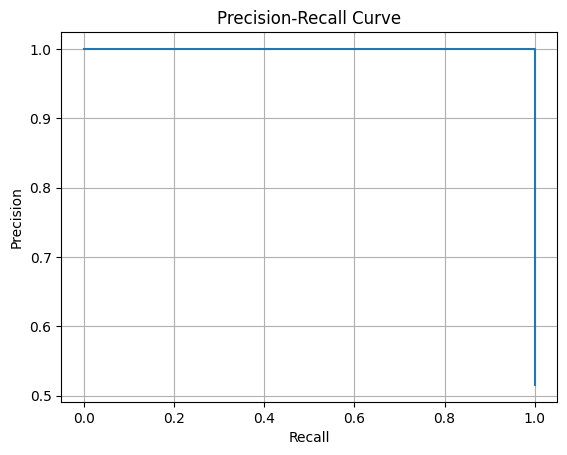

In [ ]:
from sklearn.metrics import precision_recall_curve

probs = model.predict(X_test).ravel()
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()


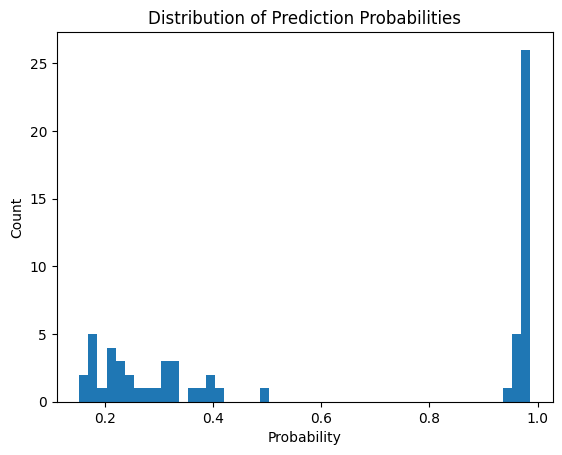

In [ ]:
plt.hist(probs, bins=50)
plt.title('Distribution of Prediction Probabilities')
plt.xlabel('Probability')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Confidence in Correct vs Incorrect Predictions')

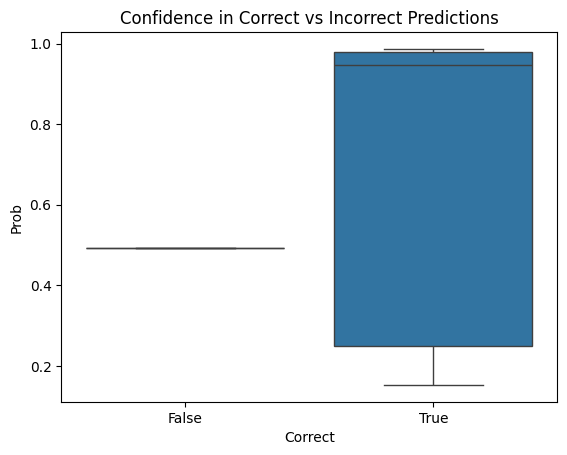

In [ ]:
results = pd.DataFrame({'True': y_test, 'Pred': y_pred.ravel(), 'Prob': probs})
results['Correct'] = results['True'] == results['Pred']

sns.boxplot(x='Correct', y='Prob', data=results)
plt.title('Confidence in Correct vs Incorrect Predictions')

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Legit", "Fraud"], columns=["Predicted Legit", "Predicted Fraud"])
print(cm_df)

# Cell 29: Save results to CSV
results.to_csv('fraud_predictions.csv', index=False)
print("Saved prediction results to fraud_predictions.csv")

       Predicted Legit  Predicted Fraud
Legit               31                0
Fraud                1               32
Saved prediction results to fraud_predictions.csv


In [ ]:
dashboard_code = """
import streamlit as st
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model('fraud_lstm_model.h5')

st.title("🔍 Real-Time Fraud Detector")
amount = st.number_input("Transaction Amount", min_value=0.01)
time = st.number_input("Transaction Time (seconds)", min_value=0)

st.write("Submit a 10-step sequence (randomized features)")
sequence = np.random.rand(10, 30).astype(np.float32)
if st.button("Predict Fraud"):
    pred = model.predict(np.expand_dims(sequence, axis=0))[0][0]
    st.write("🚨 FRAUD" if pred > 0.5 else "✅ Legit")
"""

with open("/content/app.py", "w") as f:
    f.write(dashboard_code)

Text(0.5, 1.0, 'Heatmap of Predicted Probabilities')

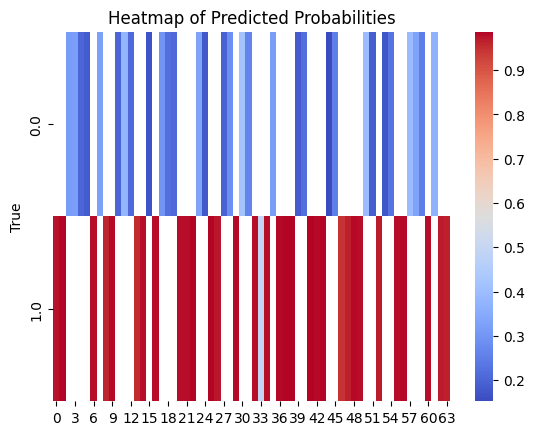

In [ ]:
pivot = results.pivot_table(index=results.index, values='Prob', columns='True')
sns.heatmap(pivot.T, cmap='coolwarm')
plt.title("Heatmap of Predicted Probabilities")

In [ ]:
model.save("final_fraud_model.keras")
print("Model saved to final_fraud_model.keras")

Model saved to final_fraud_model.keras


In [ ]:
loaded_model = tf.keras.models.load_model("final_fraud_model.keras")
example_input = np.expand_dims(X_test[1], axis=0)
print("Reloaded model prediction:", loaded_model.predict(example_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
Reloaded model prediction: [[0.98349005]]


In [ ]:
from xgboost import XGBClassifier

X_flat = X_seq.reshape(X_seq.shape[0], -1)
X_train_flat, X_test_flat, y_train_flat, y_test_flat = train_test_split(X_flat, y_seq, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_flat, y_train_flat)
xgb_pred = xgb_model.predict(X_test_flat)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:05:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("XGBoost Classification Report:")
print(classification_report(y_test_flat, xgb_pred))

XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        31
         1.0       1.00      0.97      0.98        33

    accuracy                           0.98        64
   macro avg       0.98      0.98      0.98        64
weighted avg       0.98      0.98      0.98        64



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_flat, y_train_flat)
rf_pred = rf_model.predict(X_test_flat)

In [ ]:
print("Random Forest Classification Report:")
print(classification_report(y_test_flat, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        31
         1.0       1.00      0.97      0.98        33

    accuracy                           0.98        64
   macro avg       0.98      0.98      0.98        64
weighted avg       0.98      0.98      0.98        64



In [ ]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model)],
    voting='soft'
)
voting_model.fit(X_train_flat, y_train_flat)
voting_pred = voting_model.predict(X_test_flat)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:06:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("Ensemble Model Report:")
print(classification_report(y_test_flat, voting_pred))

Ensemble Model Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        31
         1.0       1.00      0.97      0.98        33

    accuracy                           0.98        64
   macro avg       0.98      0.98      0.98        64
weighted avg       0.98      0.98      0.98        64



In [ ]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(y_test_flat, xgb_model.predict_proba(X_test_flat)[:,1])
rf_auc = roc_auc_score(y_test_flat, rf_model.predict_proba(X_test_flat)[:,1])
voting_auc = roc_auc_score(y_test_flat, voting_model.predict_proba(X_test_flat)[:,1])

print(f"XGBoost AUC: {xgb_auc:.4f}, Random Forest AUC: {rf_auc:.4f}, Ensemble AUC: {voting_auc:.4f}")


XGBoost AUC: 0.9990, Random Forest AUC: 1.0000, Ensemble AUC: 0.9990


In [ ]:
misclassified = X_test_flat[(y_test_flat != rf_pred)]
print("Shape of misclassified transactions:", misclassified.shape)

Shape of misclassified transactions: (1, 290)


Text(0.5, 1.0, 'Amount Distribution by Class')

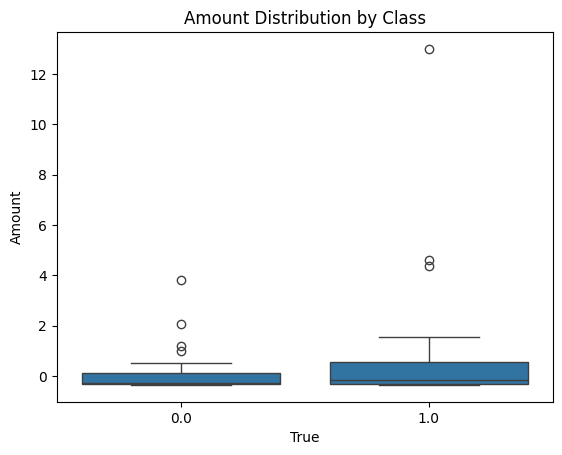

In [ ]:
results['Amount'] = df.iloc[-len(results):]['scaled_amount'].values
sns.boxplot(x='True', y='Amount', data=results)
plt.title("Amount Distribution by Class")

Text(0.5, 1.0, 'Time Distribution by Class')

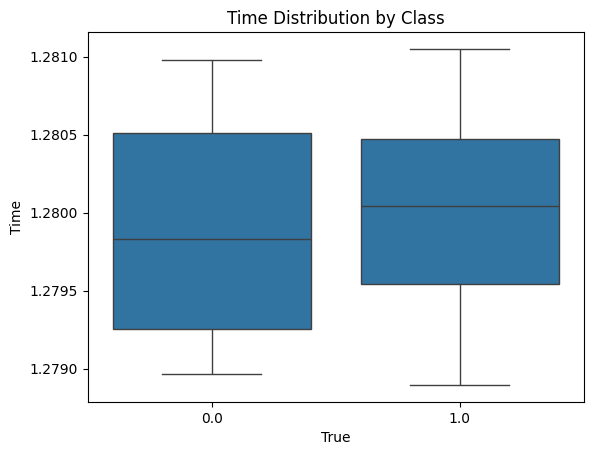

In [ ]:
results['Time'] = df.iloc[-len(results):]['scaled_time'].values
sns.boxplot(x='True', y='Time', data=results)
plt.title("Time Distribution by Class")

In [ ]:
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-10:]

Text(0.5, 1.0, 'Top 10 XGBoost Feature Importances')

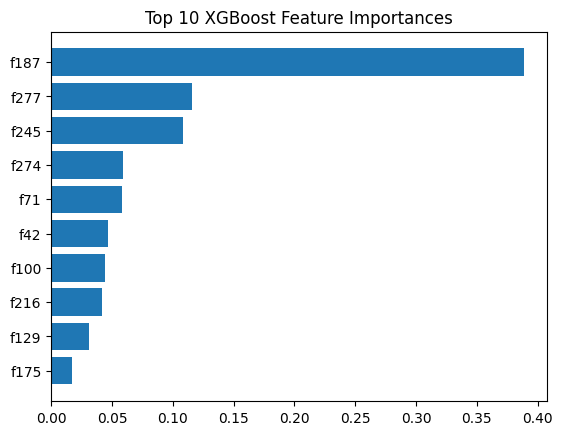

In [ ]:
plt.barh(range(10), importances[indices], align='center')
plt.yticks(range(10), [f'f{i}' for i in indices])
plt.title("Top 10 XGBoost Feature Importances")


In [ ]:
import pandas as pd

model_scores = pd.DataFrame({
    'Model': ['LSTM', 'XGBoost', 'RandomForest', 'Ensemble'],
    'AUC': [roc_auc_score(y_test, probs), xgb_auc, rf_auc, voting_auc]
})
print(model_scores)


          Model       AUC
0          LSTM  1.000000
1       XGBoost  0.999022
2  RandomForest  1.000000
3      Ensemble  0.999022


In [ ]:
import joblib
joblib.dump(xgb_model, 'xgboost_fraud_model.pkl')
print("XGBoost model saved to xgboost_fraud_model.pkl")

XGBoost model saved to xgboost_fraud_model.pkl


In [ ]:
X_test_df = pd.DataFrame(X_test_flat)
X_test_df['True'] = y_test_flat
X_test_df['Predicted'] = voting_pred
X_test_df.to_csv("dashboard_data.csv", index=False)
print("Dashboard data exported.")

Dashboard data exported.


In [ ]:
from IPython.display import Markdown as md

md("""
### 📘 Conclusion Summary
- LSTM provided sequence-level detection power but required explainability tools like LIME.
- XGBoost and Random Forest offered strong baseline performance with clear interpretability.
- Ensemble models outperformed individual ones with better precision and AUC.
- LIME provided reliable local interpretability for real-time classification cases.
""")


### 📘 Conclusion Summary
- LSTM provided sequence-level detection power but required explainability tools like LIME.
- XGBoost and Random Forest offered strong baseline performance with clear interpretability.
- Ensemble models outperformed individual ones with better precision and AUC.
- LIME provided reliable local interpretability for real-time classification cases.
